# Fieldtrip: Audio vs Motor Spatio-temporal clustering

Lead authors: Hadi Zaatiti <hz3752@nyu.edu>

- Description of experiment
The `Audio vs Visual vs Motor` code experiment in `Psychtoolbox` can be found here:

[Auditory vs Visual vs Motor](https://github.com/Hzaatiti/meg-pipeline/blob/main/experiments/psychtoolbox/auditory-vs-visual/auditory_vs_visual.m)


## Contributing

If you would like to contribute to this MATLAB-based notebook see [MATLAB Kernel Setup Instructions](../../../1-lab-overview/6-neurowaves-contribution.rst#setting-up-matlab-kernel-for-jupyter)

## Importing data 


The data used in this notebook is hosted on `NYU BOX`. Permissions are given upon request.

- Install the BOX app from [here](https://www.box.com/resources/downloads)
- Set an environment variable with name `MEG_DATA` to the path of the Data folder e.g.,
    - `C:\Users\user_name\Box\MEG\Data`
    - or `C:\Users\user_name\Box\Data

## MATLAB setup


Make sure that:
- Fieldtrip is installed in MATLAB
- Add to MATLAB path the custom-made functions for NYUAD MEG lab found [here](https://github.com/BioMedicalImaging-Core-NYUAD/neurowaves-lab-documentation/tree/main/pipeline/field_trip_pipelines/matlab_functions)  


## Spatio-temporal clustering using Fieldtrip of MEG-Axial Gradiometers data


Reference tutorial applied in this notebook: https://www.fieldtriptoolbox.org/tutorial/stats/cluster_permutation_timelock/

In this notebook, we will apply spatio-temporal clustering on a within-subject data. The reader is supposed to have understood spatio-temporal clustering technique, the notebook is meant for applying such algorithm on an NYUAD acquired dataset and not detailing the method itself.

### Importing visual and audio trials

Let's start off by defining the path to our MEG pre-processed trials

In [24]:
% Read the environment variable to NYU BOX
MEG_DATA_FOLDER = getenv('MEG_DATA');


% Define paths
TASK_NAME = 'audio-visual-motor';
SYSTEM = 'meg';
SUB_ID = 'sub-001';
SESSION_ID = 'ses-01';
DERIVATIVES = 'derivatives';
PIPELINE = 'fieldtrip_trials_preprocessed';


% Construct the directory path
DATA_FOLDER_PATH = fullfile(MEG_DATA_FOLDER, TASK_NAME, SUB_ID, SESSION_ID, SYSTEM);
TRIALS_FOLDER_PATH = fullfile(MEG_DATA_FOLDER, TASK_NAME, DERIVATIVES, PIPELINE, SUB_ID, SESSION_ID);


Load the visual and motor trials into the memory then display their shape.
The visual trials correspond to a strong visual flash while the motor trials correspond to a button press.
The trials are output of `ft_preprocessing` or similar structured output

In [15]:
load(fullfile(TRIALS_FOLDER_PATH, 'trials_visual.mat'));
load(fullfile(TRIALS_FOLDER_PATH, 'trials_motor.mat'));

trials_visual
trials_motor


trials_visual = 

  struct with fields:

         label: {207×1 cell}
     trialinfo: [141×1 double]
    sampleinfo: [141×2 double]
          grad: [1×1 struct]
         trial: {1×141 cell}
          time: {1×141 cell}
       fsample: 1000
           cfg: [1×1 struct]


trials_motor = 

  struct with fields:

         label: {207×1 cell}
     trialinfo: [146×1 double]
    sampleinfo: [146×2 double]
          grad: [1×1 struct]
         trial: {1×146 cell}
          time: {1×146 cell}
       fsample: 1000
           cfg: [1×1 struct]




Spatio-temporal clustering within subject, will compare the MEG measurements for each sample pair (channel, time point) across conditions.
In this notebook we are considering two conditions, the visual one and motor one.
The comparison is based on attempting to find "significant" clusters selected from samples selected, themselves, according to a statistical t-test.

The statistical t-test is performed for each sample pair (channel, time point) across conditions and requires knowing the mean of the measurement across trials from condition 1 and the mean across condition 2, aswell as the spread over each group of trials.

Let us compute the averaged trials, while keeping the measurement of each trial.

In [16]:
cfg = [];
cfg.keeptrials = 'yes';

timelock_visual = ft_timelockanalysis(cfg, trials_visual)
timelock_motor = ft_timelockanalysis(cfg, trials_motor)

the input is raw data with 207 channels and 141 trials
the call to "ft_selectdata" took 0 seconds
the call to "ft_timelockanalysis" took 2 seconds

timelock_visual = 

  struct with fields:

          time: [-0.5000 -0.4990 -0.4980 -0.4970 -0.4960 -0.4950 -0.4940 -0.4930 -0.4920 -0.4910 -0.4900 -0.4890 -0.4880 -0.4870 -0.4860 -0.4850 -0.4840 -0.4830 -0.4820 -0.4810 -0.4800 -0.4790 … ] (1×1700 double)
         label: {207×1 cell}
          grad: [1×1 struct]
    sampleinfo: [141×2 double]
         trial: [141×207×1700 double]
     trialinfo: [141×1 double]
        dimord: 'rpt_chan_time'
           cfg: [1×1 struct]

the input is raw data with 207 channels and 146 trials
the call to "ft_selectdata" took 0 seconds
the call to "ft_timelockanalysis" took 2 seconds

timelock_motor = 

  struct with fields:

          time: [-0.5000 -0.4990 -0.4980 -0.4970 -0.4960 -0.4950 -0.4940 -0.4930 -0.4920 -0.4910 -0.4900 -0.4890 -0.4880 -0.4870 -0.4860 -0.4850 -0.4840 -0.4830 -0.4820 -0.4810 -0.4800 -

We will not define the spatio-temporal clustering parameters, the full details of how these parameters affect the analysis should be understood from the referenced fieldtrip tutorial and the original referenced papers.

In [17]:
cfg = [];
cfg.method='montecarlo'; % we will define a certain number of permutation and perform purely randomly number of permutations
cfg.statistic = 'indepsamplesT'; % t-value is attributed per sample

cfg.correctm = 'cluster';
cfg.clusteralpha = 0.05;   % threshold level for identifying "good" samples with best t-values
cfg.clusterstatistic= 'maxsum';
cfg.minnbchan = 2;  % Minimum number of channels that are in the neighborhood of a sample, to be included in the clustering algorithm
% (It will still have to pass the alpha threshold constraint)

cfg.tail = 0;  % one-sided or two sided test
cfg.clusterail=0;

% Neighbours prepare
ncfg = [];
ncfg.method = 'distance';
ncfg.grad = timelock_visual.grad;
neighbours = ft_prepare_neighbours(ncfg);

cfg.neighbours = neighbours;
cfg.alpha = 0.025;  % threshold of the permutation test (not exactly sure what that is)
cfg.numrandomization = 10000;

n_visual = size(timelock_visual.trial, 1);

n_motor = size(timelock_motor.trial, 1);

cfg.design           = [ones(1,n_visual), ones(1,n_motor)*2]; % design matrix
cfg.ivar             = 1; % number or list with indices indicating the independent variable(s)

cfg.channel       = {'AG*'};     % cell-array with selected channel labels
cfg.latency       = [0 1];       % time interval over which the experimental
                                 % conditions must be compared (in seconds)

using gradiometers specified in the configuration
using a distance threshold of 4
there are on average 6.2 neighbours per channel
the call to "ft_prepare_neighbours" took 1 seconds



### Statistics computation with permutation tests

Execute the statistics computation. We picked a high number for the permutation (cfg.numrandomization) to get a better approximation of the p-value.
This will take a while, for testing purposes go with a small number of permutation (e.g., 100) then attempt a higher one.

In [18]:
[stat] = ft_timelockstatistics(cfg, timelock_visual, timelock_motor);


save stat_visual_motor stat;

the call to "ft_selectdata" took 1 seconds
using specified neighbours for the channels
there are on average 6.2 neighbours per channel
the call to "ft_prepare_neighbours" took 0 seconds
using "ft_statistics_montecarlo" for the statistical testing
using "ft_statfun_indepsamplesT" for the single-sample statistics
constructing randomized design
total number of measurements     = 287
total number of variables        = 1
number of independent variables  = 1
number of unit variables         = 0
number of within-cell variables  = 0
number of control variables      = 0
using a permutation resampling approach
computing a parametric threshold for clustering
computing statistic
estimated time per randomization is 3.08 seconds
computing statistic 1 from 10000
computing statistic 2 from 10000
computing statistic 3 from 10000
computing statistic 4 from 10000
computing statistic 5 from 10000
computing statistic 6 from 10000
computing statistic 7 from 10000
computing statistic 8 from 10000
com

Lets print some metrics regarding the best clusters (lowest p-value)

In [19]:
stat.posclusters(1)

stat.negclusters(1)


ans = 

  struct with fields:

           prob: 7.9992e-04
    clusterstat: 2.7990e+04
         stddev: 2.8272e-04
        cirange: 5.5412e-04


ans = 

  struct with fields:

           prob: 1.9998e-04
    clusterstat: -7.7783e+04
         stddev: 1.4140e-04
        cirange: 2.7714e-04




To visualise the clusters, it is interesting to do a substraction of the measurements from each condition over the trials.
Let's first compute the averaged trials for each condition and then the substraction.

In [20]:
% Average the trials
cfg = [];
avg_visual = ft_timelockanalysis(cfg, trials_visual);
avg_motor = ft_timelockanalysis(cfg, trials_motor);

% Find the difference of the average
cfg = [];
cfg.operation = 'subtract';
cfg.parameter = 'avg';
raweffectVisualvsMotor = ft_math(cfg, avg_visual, avg_motor);

the input is raw data with 207 channels and 141 trials
the call to "ft_selectdata" took 0 seconds
the call to "ft_timelockanalysis" took 3 seconds
the input is raw data with 207 channels and 146 trials
the call to "ft_selectdata" took 0 seconds
the call to "ft_timelockanalysis" took 3 seconds
the call to "ft_selectdata" took 0 seconds
selecting avg from the first input argument
subtracting the 2nd input argument from the 1st
the call to "ft_math" took 1 seconds



We can now select from the computed clusters, the ones that satisfy a threshold on the p-value.
In this notebook we picked `p<0.025`

In [21]:
pos_cluster_pvals = [stat.posclusters(:).prob];

pos_clust = find(pos_cluster_pvals<0.025);
pos = ismember(stat.posclusterslabelmat, pos_clust);

% and now for the negative clusters...
neg_cluster_pvals = [stat.negclusters(:).prob];
neg_clust         = find(neg_cluster_pvals < 0.025);
neg               = ismember(stat.negclusterslabelmat, neg_clust);

We now identified the "best" clusters, we can plot on the substracted data, for several time points the averaged subtracted measurement, while visualising the selected clusters aswell. 
First let's create the sensor layout for the NYUAD-KIT MEG system.

found matching BIDS sidecar 'C:\Users\hz3752\Box\MEG\Data\audio-visual-motor\sub-001\ses-01\meg\sub-001_ses-01_task-audiovisualmotor_meg.json'
reading 'C:\Users\hz3752\Box\MEG\Data\audio-visual-motor\sub-001\ses-01\meg\sub-001_ses-01_task-audiovisualmotor_meg.json'
creating layout from cfg.grad
creating layout for yokogawa208 system
the call to "ft_prepare_layout" took 0 seconds
reading layout from file CTF151.lay
the call to "ft_prepare_layout" took 0 seconds



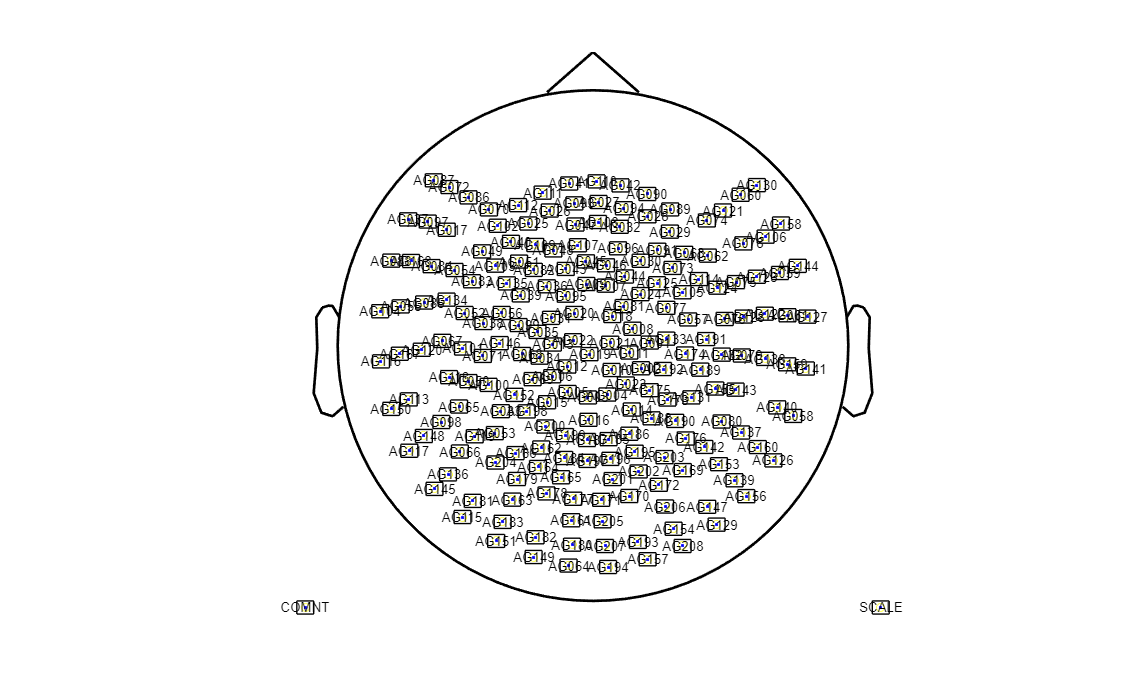

In [26]:

% List all .con files with the prefix 'sub-001'
filePattern = fullfile(DATA_FOLDER_PATH, [SUB_ID,'*.con']);
conFiles = dir(filePattern);
conFile = fullfile(DATA_FOLDER_PATH, conFiles(k).name);

kit_layout = create_kit_layout(conFile);

figure('Position', [100, 100, 1000, 800]); % Adjust the width and height (1000 and 800) as needed
ft_plot_layout(kit_layout, 'box', 1);

Let's define the plotting parameters

In [27]:
timestep      = 0.05; % timestep between time windows for each subplot (in seconds)
sampling_rate = trials_visual.fsample; % Data has a temporal resolution of 300 Hz
sample_count  = length(stat.time);
% number of temporal samples in the statistics object
j = [0:timestep:1]; % Temporal endpoints (in seconds) of the ERP average computed in each subplot
m = [1:timestep*sampling_rate:sample_count]; % temporal endpoints in M/EEG samples

We are now ready to plot the data at the defind timesteps.

the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 3 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 3 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 2 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 3 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 3 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 3 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 3 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_select

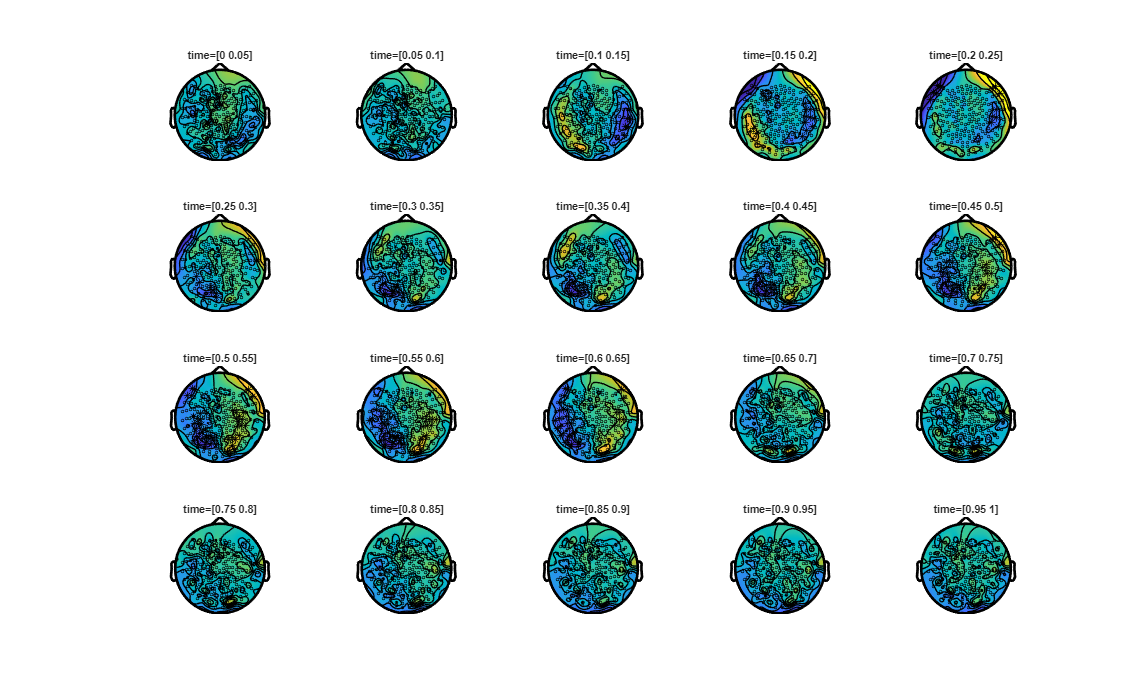

In [28]:
% First ensure the channels to have the same order in the average and in the statistical output.
% This might not be the case, because ft_math might shuffle the order
[i1,i2] = match_str(raweffectVisualvsMotor.label, stat.label);

for k = 1:20
   subplot(4,5,k);
   cfg = [];
   cfg.xlim = [j(k) j(k+1)];   % time interval of the subplot
   cfg.zlim = [-2.5e-13 2.5e-13];
   % If a channel is in a to-be-plotted cluster, then
   % the element of pos_int with an index equal to that channel
   % number will be set to 1 (otherwise 0).

   % Next, check which channels are in the clusters over the
   % entire time interval of interest.
   pos_int = zeros(numel(raweffectVisualvsMotor.label),1);
   neg_int = zeros(numel(raweffectVisualvsMotor.label),1);
   pos_int(i1) = all(pos(i2, m(k):m(k+1)), 2);
   neg_int(i1) = all(neg(i2, m(k):m(k+1)), 2);

   cfg.highlight   = 'on';
   % Get the index of the to-be-highlighted channel
   cfg.highlightchannel = find(pos_int | neg_int);
   cfg.comment     = 'xlim';
   cfg.commentpos  = 'title';
   cfg.layout      = kit_layout;
   cfg.interactive = 'no';
   cfg.figure      = 'gca'; % plots in the current axes, here in a subplot
   ft_topoplotER(cfg, raweffectVisualvsMotor);
end

## Spatio-temporal clustering using Fieldtrip using MEG-planar gradiometer data synthetised from the raw axial-gradiometer data

In this section we will reperform the previous analysis using Fieldtrip, but we will first transform the raw axial-gradiometer data to planar-gradiometer data. We will call the transformed planar-gradiometer data synthetic, since the MEG-system itself did not generate it.

- Axial gradiometer data: The peaks on axial-gradiometer data do not correspond to actual activity sources, but correspond to the peaks in the measured magnetic field at that location. The two pick-up coils are slightly offset spatially from each other on the radial axis, i.e., the axis linking the center of the MEG-helmet to the sensor.
- Planar gradiometer data: The peaks on planar-gradiometer data correspond to actual activity sources. When there is an activity source at some location in the brain, it is often well-localized and not dispersed all over the brain. The MEG measurements preserve better the spatial properties of the activity than EEG recording. The MEG measurements obtained using planar-gradiometers would often show a peak centered on the activity epicenter with a steep gradient as we get away from the peak (just like a sharp-edged mountain). The two pick-up coils of the planar gradiometer are tangentially slightly offset spatially from each other to the surface of the MEG-helmet. Therefore, planar-gradiometers measure the spatial difference in the activity over the helmet surface, their measurement is a good detector of how steep the gradient of the activity is. Consequently, near the source, they can indicate the presence its presence since they detect the steep gradient surrounding the source. This would not be true if the peak activity is smoothly spread on the helmet surface, but this is unlikely in MEG. 


Let us apply the planar gradiometer transformation to the axial-gradiometer MEG data

In [2]:
cfg = [];
cfg.planarmethod   = 'sincos';
cfg.neighbours     = neighbours; % also here, neighbouring sensors needs to be defined
timelock_visual_planar = ft_megplanar(cfg, timelock_visual);
timelock_motor_planar  = ft_megplanar(cfg, timelock_motor);

timelock_visual_planar_cmb = ft_combineplanar(cfg, timelock_visual_planar);
timelock_motor_planar_cmb  = ft_combineplanar(cfg, timelock_motor_planar);

timelock_visual_planar_cmb.grad = timelock_visual.grad;  % add the gradiometer structure
timelock_motor_planar_cmb.grad  = timelock_motor.grad;

the input is timelock data with 207 channels and 1700 timebins
constructing trials from "trial"
using specified neighbours for the channels
there are on average 6.2 neighbours per channel
the call to "ft_prepare_neighbours" took 0 seconds
the call to "ft_selectdata" took 0 seconds
average number of neighbours is 6.19
minimum distance between neighbours is   1.64 cm
maximum distance between gradiometers is   3.99 cm
processing trials
processing trial 11 from 141
processing trial 20 from 141
processing trial 39 from 141
processing trial 54 from 141
processing trial 73 from 141
processing trial 95 from 141
processing trial 107 from 141
processing trial 117 from 141
processing trial 136 from 141
processing trial 141 from 141

the call to "ft_megplanar" took 5 seconds
the input is timelock data with 207 channels and 1700 timebins
constructing trials from "trial"
using specified neighbours for the channels
there are on average 6.2 neighbours per channel
the call to "ft_prepare_neighbou

Let's do a topolot to compare the raw axial gradiometer data and the synthetic planar-data.
We will plot the visual stimuli MEG-measurements at the 70-120ms time window.

the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 1 seconds
the call to "ft_prepare_layout" took 0 seconds
the call to "ft_selectdata" took 0 seconds
the call to "ft_topoplotER" took 1 seconds



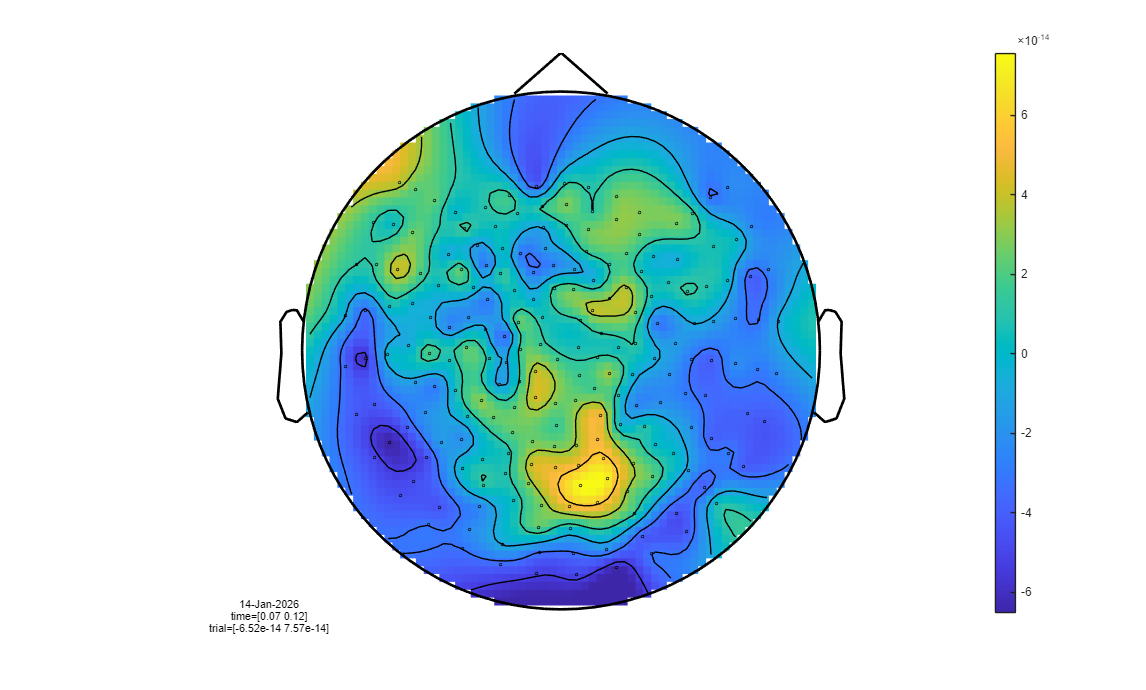

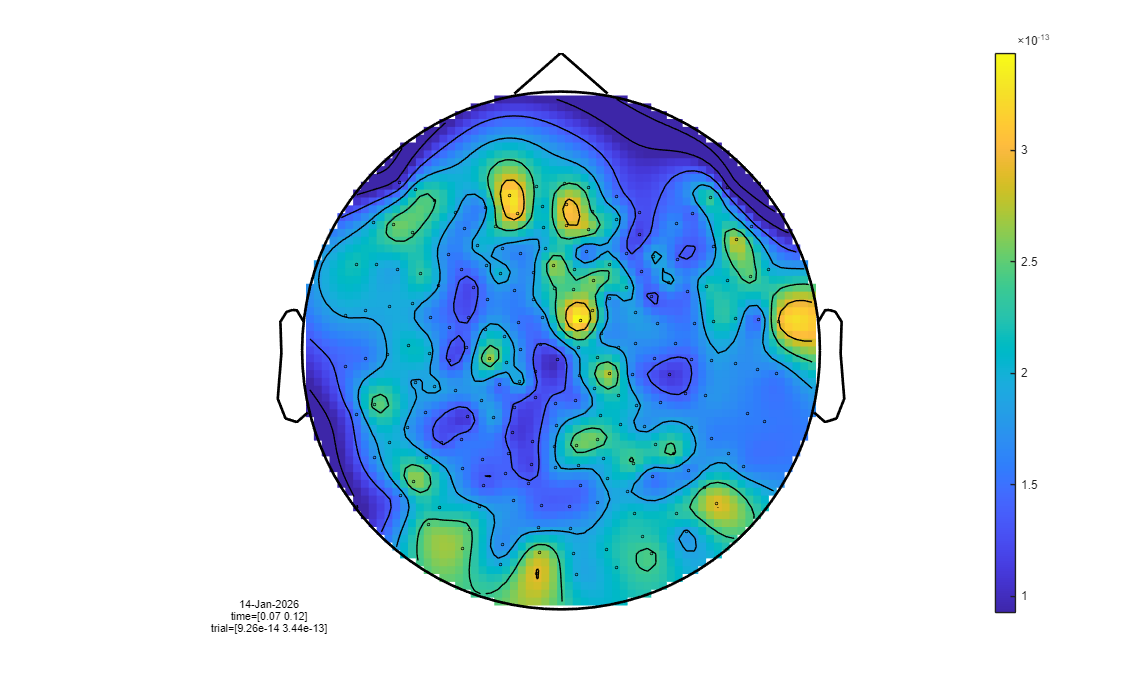

In [4]:
    cfg = [];
    cfg.xlim = [0.07 0.120];
    cfg.colorbar = 'yes';
    cfg.layout = kit_layout;
    cfg.readbids = 'no';
    ft_topoplotER(cfg, timelock_visual);
    %shg;            % "Show Graph" - forces the window to the front

    cfg = [];
    cfg.xlim = [0.07 0.120];
    cfg.colorbar = 'yes';
    cfg.layout = kit_layout;
    cfg.readbids = 'no';
    ft_topoplotER(cfg, timelock_visual_planar_cmb);